In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.systems.framework import DiagramBuilder
from pydrake.multibody.parsing import Parser
import os
from pydrake.all import (
    LoadModelDirectives, ProcessModelDirectives, RevoluteJoint, 
    RationalForwardKinematics, CspaceFreePolytope, SeparatingPlaneOrder,
    RigidTransform, RotationMatrix, Rgba,
    AffineSubspace, MathematicalProgram, Solve,
    MeshcatVisualizer, StartMeshcat,
    LoadIrisRegionsYamlFile, ModelVisualizer,
    PointCloud
)
import numpy as np
# from pydrake.geometry.optimization_dev import (CspaceFreePolytope, SeparatingPlaneOrder)
from iris_plant_visualizer import IrisPlantVisualizer
from pydrake.geometry import Role
from pydrake.geometry.optimization import IrisOptions, HPolyhedron, Hyperellipsoid, IrisInRationalConfigurationSpace
from pydrake.solvers import MosekSolver, CommonSolverOption, SolverOptions, ScsSolver
import time
from pgd import *

from manipulation.utils import ConfigureParser
from manipulation.scenarios import AddPlanarIiwa, AddShape, AddWsg
import sys
from util import remap_and_toppra_trajectory, build_env, plot_traj_end_effector_path
from pydrake.all import MultibodyPositionToGeometryPose, TrajectorySource, Simulator, InverseKinematics

# set up the certifier and the options for different search techniques
solver_options = SolverOptions()
# set this to 1 if you would like to see the solver output in terminal.
solver_options.SetOption(CommonSolverOption.kPrintToConsole, 1)

os.environ["MOSEKLM_LICENSE_FILE"] = "/home/sgrg/mosek.lic"
with open(os.environ["MOSEKLM_LICENSE_FILE"], 'r') as f:
    contents = f.read()
    mosek_file_not_empty = contents != ''
print(mosek_file_not_empty)

solver_id = MosekSolver.id() if MosekSolver().available() and mosek_file_not_empty else ScsSolver.id()

import logging
dk_log = logging.getLogger("drake")
dk_log.setLevel(logging.DEBUG)
dk_log.getChild("Snopt").setLevel(logging.INFO)

True


In [75]:
#construct our robot
from pydrake.all import InverseKinematics, Sphere

builder = DiagramBuilder()

plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)
ConfigureParser(parser)
iiwa = AddPlanarIiwa(plant)
wsg = AddWsg(plant, iiwa, roll=0.0, welded=True)
sphere = AddShape(plant, Sphere(0.02), "sphere")
X_WO = RigidTransform([0.6, 0, 0.65])
plant.WeldFrames(plant.world_frame(), plant.GetFrameByName("sphere"), X_WO)
bi = parser.AddModelsFromUrl("package://manipulation/shelves.sdf")[0]
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("shelves_body", bi),
    RigidTransform([0.8, 0, 0.4]),
    )

plant.Finalize()
meshcat = StartMeshcat()
MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
diagram = builder.Build()

context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(context)

q0 = plant.GetPositions(plant_context)
gripper_frame = plant.GetFrameByName("body", wsg)
sphere_frame = plant.GetFrameByName("sphere", sphere)

ik = InverseKinematics(plant, plant_context)
collision_constraint = ik.AddMinimumDistanceLowerBoundConstraint(0.001, 0.01)
grasp_constraint = ik.AddPositionConstraint(
    gripper_frame, [0, 0.1, 0], sphere_frame, [0, 0, 0], [0, 0, 0]
)

prog = ik.get_mutable_prog()
q = ik.q()
prog.SetInitialGuess(q, q0)
result = Solve(ik.prog())
if not result.is_success():
    print("IK failed")

diagram.ForcedPublish(context)

Ratfk = RationalForwardKinematics(plant)

# the point about which we will take the stereographic projections
# q_star = np.zeros(plant.num_positions())
q_star = np.array([0.0,0.0,0.0])
do_viz = True

# The object we will use to perform our certification.
cspace_free_polytope = CspaceFreePolytope(plant, scene_graph, SeparatingPlaneOrder.kAffine, q_star)

DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindCache found /home/sgrg/.cache/drake
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:ParseModelDirectivesImpl(MultibodyPlant)
DEBUG:drake:  add_model: gripper
    package://manipulation/schunk_wsg_50_welded_fingers.sdf
DEBUG:drake:SDFormat Dbg [parser.cc:1096] Converting a deprecated source[/home/sgrg/rlg/manipulation/manipulation/models/schunk_wsg_50_welded_fingers.sdf].
DEBUG:drake:SDFormat D

IK failed


In [4]:
for varq in q:
    print(result.GetSolution(varq))

0.22779647389084973
-1.033717515079888
1.404285299646268


In [5]:
def visualise_IRIS(regions, plant, plant_context, seed=42, num_sample=10000, colors=None):       
    world_frame = plant.world_frame()
    ee_frame = plant.GetFrameByName("iiwa_frame_ee")

    rng = RandomGenerator(seed)

    # Allow caller to input custom colors
    if colors is None:
        colors = [
                    Rgba(0.5,0.0,0.0,0.5),
                    Rgba(0.0,0.5,0.0,0.5),
                    Rgba(0.0,0.0,0.5,0.5),
                    Rgba(0.5,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.5,0.5),
                    Rgba(0.2,0.2,0.2,0.5),
                    Rgba(0.5,0.2,0.0,0.5),
                    Rgba(0.2,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.2,0.5),
                    Rgba(0.2,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.2,0.5),
                    Rgba(0.0,0.2,0.5,0.5),
                ]

    for i in range(len(regions)):
        region = regions[i]

        xyzs = []  # List to hold XYZ positions of configurations in the IRIS region

        rq_sample = region.UniformSample(rng)
        q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

        plant.SetPositions(plant_context, q_sample)
        xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        for _ in range(num_sample-1):
            prev_sample = rq_sample
            rq_sample = region.UniformSample(rng, prev_sample)
            q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

            plant.SetPositions(plant_context, q_sample)
            xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        # Create pointcloud from sampled point in IRIS region in order to plot in Meshcat
        xyzs = np.array(xyzs)
        pc = PointCloud(len(xyzs))
        pc.mutable_xyzs()[:] = xyzs.T
        meshcat.SetObject(f"regions/region {i}", pc, point_size=0.025, rgba=colors[i % len(colors)])

DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001


In [6]:
iris_options = IrisOptions()
iris_options.require_sample_point_is_contained = True
iris_options.configuration_space_margin = 0.0001
iris_options.relative_termination_threshold = 0.001
iris_options.iteration_limit = 10

def in_collision(plant, scene_graph, context, print_collisions=False, thresh=1e-3):
    plant_context = plant.GetMyContextFromRoot(context)
    sg_context = scene_graph.GetMyContextFromRoot(context)
    query_object = plant.get_geometry_query_input_port().Eval(plant_context)
    inspector = scene_graph.get_query_output_port().Eval(sg_context).inspector()
    pairs = inspector.GetCollisionCandidates()
    dists = []
    for pair in pairs:
        dists.append(query_object.ComputeSignedDistancePairClosestPoints(pair[0], pair[1]).distance)
        if dists[-1] < thresh and print_collisions:
            print(inspector.GetName(inspector.GetFrameId(pair[0])),
                  inspector.GetName(inspector.GetFrameId(pair[1])))
    return np.min(dists) < thresh

def grow_region(q):
    name = str(q)    
    t1 = time.time()
    plant.SetPositions(plant.GetMyMutableContextFromRoot(context), q)
    r = IrisInRationalConfigurationSpace(plant, 
                                         plant.GetMyContextFromRoot(context),
                                         q_star, iris_options)
    t2 = time.time()
    print("Region constructed in ~%d seconds." % int(t2 - t1))
    return r

DEBUG:drake:Meshcat: GET /


In [130]:
from pydrake.all import LoadIrisRegionsYamlFile
regions_dict = LoadIrisRegionsYamlFile("/home/sgrg/rlg/SUPERUROP/ciris/1028/certified_regions_2.yaml")
all_regions = [r for r in regions_dict.values()]

In [131]:
from util import notebook_plot_connectivity

DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will us

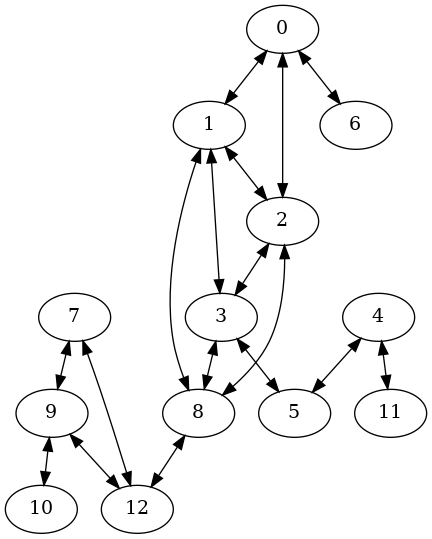

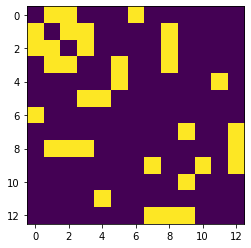

Graph has 1 connected components.


In [132]:
notebook_plot_connectivity(all_regions)

In [10]:
from manipulation.exercises.trajectories.rrt_planner.robot import (
    ConfigurationSpace,
    Range,
)
q_low = np.array([-3.094395,-3.094395,-3.094395])
q_high = np.array([3.094395,3.094395,3.094395])

joint_limits = np.zeros((3, 2))
idx, i = 0, 0
for joint_index in plant.GetJointIndices():
    joint = plant.get_mutable_joint(joint_index)
    if isinstance(joint, RevoluteJoint):
        joint.set_default_angle(q0[idx])
        joint.set_position_limits(lower_limits= np.array([q_low[idx]]), upper_limits= np.array([q_high[idx]]))
        idx += 1
        joint_limits[i, 0] = joint.position_lower_limits()
        joint_limits[i, 1] = joint.position_upper_limits()
        i += 1

range_list = []
for joint_limit in joint_limits:
    range_list.append(Range(joint_limit[0], joint_limit[1]))

def l2_distance(q: tuple):
    sum = 0
    for q_i in q:
        sum += q_i**2
    return np.sqrt(sum)

max_steps = 3 * [np.pi / 180 * 2]  # three degrees
cspace = ConfigurationSpace(range_list, l2_distance, max_steps)

/tmp/ipykernel_569090/497532250.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  joint_limits[i, 0] = joint.position_lower_limits()
/tmp/ipykernel_569090/497532250.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  joint_limits[i, 1] = joint.position_upper_limits()


In [186]:
start = all_regions[6].ChebyshevCenter()
goal = all_regions[5].ChebyshevCenter()

DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek


In [187]:
# start = Ratfk.ComputeSValue(start_q, q_star)
# goal = Ratfk.ComputeSValue(end_q, q_star)
for region in regions_dict:
    if regions_dict[region].PointInSet(start):
        print(region, " has point start")
    if regions_dict[region].PointInSet(goal):
        print(region, " has point goal")

middle_smallj  has point goal
nice_bottomj  has point start


In [188]:
# start_q = [-2.07866489,  1.35673243, -0.4646844,  -0.70263122,  0.52685627,  1.38673004, 0.0]
# start = Ratfk.ComputeSValue(start_q, q_star)
# start_q = Ratfk.ComputeQValue(regions_dict['rbin1'].Projection(start)[1], q_star)
# print(start_q)
# end_q = [2.0742509, 1.19629798, 0.48247359, -1.07257041, 0.0976926, 0.2769091, 0.0]

In [189]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 0.1
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])

            t2 = time.perf_counter()

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [190]:
order = 5

In [193]:
ORDER = order
gcs, flows_result = generate_flows(start, goal, ORDER, all_regions, dim=3)
print("flow generated")
start_vertex, end_vertex = prune(gcs, flows_result, epsilon=0.00001)
print("pruned")
best_path, best_rounded_result = run_dfs(flows_result, gcs, start_vertex, end_vertex, iterations=5)

DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will us

flow generated
Start vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x72d26d75e770>   and end vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x72d26d75e830>
pruned
True
found a successful path?
True
True
True
True
Cost for best path found   1.7500906913260263


In [194]:
print(best_rounded_result)

In [195]:
list(flows_result.get_x_val())

[1.0,
 0.6826947742493631,
 -1.1251706228209244,
 -0.8180310150861975,
 0.6826947725354161,
 -1.125170772790639,
 -0.8180312148637873,
 0.6862577869364402,
 -1.2751915405861654,
 -1.0475809589759641,
 0.6875498753792034,
 -1.3295959936597668,
 -1.1308263148851176,
 0.6896966932324189,
 -1.4199910146029007,
 -1.2691415225680038,
 0.6896966823649244,
 -1.4199912268655823,
 -1.26914185684236,
 0.09999999999999432,
 0.6896966823649244,
 -1.4199912268655823,
 -1.26914185684236,
 0.6896966714913022,
 -1.4199914391261825,
 -1.2691421911227494,
 0.6589296882059913,
 -1.625585363769317,
 -1.6042353897113368,
 0.6561614122914904,
 -1.6440653848722628,
 -1.6343571460202753,
 0.6515368524879239,
 -1.674909927273274,
 -1.6846349717894287,
 0.6515368495500071,
 -1.6749099283131454,
 -1.6846349750809506,
 0.1,
 0.0,
 0.0,
 -1.1102230246251565e-16,
 -2.220446049250313e-16,
 0.0,
 -1.1102230246251565e-16,
 -2.220446049250313e-16,
 0.0,
 -1.1102230246251565e-16,
 -2.220446049250313e-16,
 0.0,
 -1.110223

In [196]:
# # setup for PGD
variables, indices, h_list = generate_variable_list(best_path, ndim=3, order=ORDER)
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)

import numpy.linalg as la
# # iterate until infeasible.
# # get constraints and put into HPolyhedron - should be the same as 
prog, _ = prog_with_constraints(variables, best_path, start, goal, indices, 3, h_list)

In [197]:
print("program set")
hpoly = HPolyhedron(prog)
# is A necessary?
A = hpoly.A()
b = hpoly.b()
# create affine subspace
A_eq, b_eq = get_equality_matrices(prog)
U, S, V = la.svd(A_eq)

# nullspace is spanned by the last n-r columns of V
# rank is almost zero entries along the diagonal of S
r = (S>0.00001).sum()
basis = V[r:]
translation = la.pinv(A_eq).dot(b_eq)

affine_sub = AffineSubspace(basis.T, translation)

program set


## Running PGD

In [198]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
#         print("Getting gradients")
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)
#     print("got initial gradients and costs ", f_Rk, df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 10.0
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
#         print("in backtracking, f_k determined to be ", f_k, "Max optimal is", (f_Rk - 0.5*t*(L_norm)))
#         print("in backtracking, while condition is ", f_k > (f_Rk - 0.5*t*(L_norm)))
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
#             print("checkingwhat step to use f_k = ", f_k, "Will it work against ", f_Rk - 0.5*t*(L_norm))
            t2 = time.perf_counter()
#         print('Found step size, ', t)

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [199]:
t1_start = perf_counter() 
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)
 
iters = 50
eps = 1e-7
qps_solved = 0
iter_costs = []
x_axis = []
times = []
t_grads = []
t_bt = []
t_qp = []
bt_costs = []
time_steps = []
lnorms = []
running_qp_project = []
termin = []
total_ts = []
costs_ts = []
qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, 3, h_list)
init_values, qp_c = run_qp_proj(variables, init_values, best_path, start, goal, indices, h_list, qp)
print('setup')

DEBUG:drake:solvers::Solve will use Mosek


setup


In [200]:
from jax import grad
import jax
# define costfn
jax.clear_caches()
costfn = jax.jit(distance_for_vertex, backend="cpu")
t1 = perf_counter()
costfn(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
print("warm start costfn took ", t2 - t1)

warm start costfn took  0.21815176401287317


In [201]:
grad_cost = grad(distance_for_vertex)
grad_jit = jax.jit(grad_cost, backend='cpu')
t1 = perf_counter()
grad_jit(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
t2 - t1

1.3449261599744204

In [202]:
investigative_trajs = []
exp_avg = 0
moving_avg = 0
diff_termin = []
window = 5
i = 0
while i < 500:
    total_start = perf_counter()
    grad_time = perf_counter()
#     print('.')
#     bt_cost, bt_time, ts, l_norm = 0, 0, 0, 0
#     print("old value", init_values)
    init_values[:len(variables)], bt_cost, bt_time, ts, l_norm = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.01, backtracking=True, ndim=3)
#     print("EXPECTED COST", bt_cost)
#     print("new value", init_values)
#     init_values[:len(variables)] = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.005, backtracking=False)
    grad_time_stop = perf_counter()
#     print(grad_time_stop - grad_time)
    #### NOT TIMED #####
    t_grads.append(grad_time_stop - grad_time)
    t_bt.append(bt_time)
    bt_costs.append(bt_cost)
    time_steps.append(ts)
    lnorms.append(l_norm)
    ## NOT TIMED FIN ##
    qp_time = perf_counter()
    cheap_proj = affine_sub.Projection(init_values)[1].T[0] # DOUBLE CHECK THE SHAPE OF THIS
    if not hpoly.PointInSet(cheap_proj):
#         print("QP RUN")
        init_values, qp_c = run_qp_proj(variables, cheap_proj, best_path, start, goal, indices, h_list, qp, qp_c)
        qps_solved += 1
        running_qp_project.append(True)
    else:
#         print("Cheap affine projection worked")
        init_values = cheap_proj
        running_qp_project.append(False)
#     print("Post projection values", init_values)
    qp_time_stop = perf_counter()
    #### NOT TIMED #####
    t_qp.append(qp_time_stop - qp_time)
    cost = 0
    cost_calc_start = perf_counter()
    for v in range(len(best_path[1:-1])):
        cost += costfn(init_values[indices[v][0]:indices[v][1]])
        if cost!=cost:
            print(v, i)
    iter_costs.append(cost)
    if len(iter_costs) >= window:
        moving_avg_new = sum(iter_costs[-window:])/window
        termin.append(moving_avg_new)
        if moving_avg != 0:
            diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
        moving_avg = moving_avg_new
#     exp_avg_new = alpha * cost + (1-alpha) * exp_avg
#     exp_avg = exp_avg_new
#     if len(iter_costs) > 4:
#         moving_avg_new = sum(iter_costs[-5:])/5
#         termin.append(moving_avg_new)
#         diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
#         moving_avg = moving_avg_new
    cost_calc_stop = perf_counter()
    costs_ts.append(cost_calc_stop-cost_calc_start)
    x_axis.append(i)
    times.append(perf_counter()-t1_start)
    if i % 10 == 0:
#         qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, h_list)
        print("     ")
    print('.', end='')
    ## NOT TIMED FIN ##
    total_end = perf_counter()
    total_ts.append(total_end-total_start)
    i += 1
#     if i>70:
#         investigative_trajs.append(trajectorify_given_vars(best_path, init_values, indices))
#     else if i==79:
        
t1_stop = perf_counter() 
cost = 0
for v in range(len(best_path[1:-1])):
    cost += costfn(init_values[indices[v][0]:indices[v][1]])
times.append(perf_counter()-t1_start)
iter_costs.append(cost)
x_axis.append(i)

print("Solve time:", t1_stop - t1_start, "QPs run", qps_solved, "iteration_costs", iter_costs)

DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:dr

     
..........     
.

DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:dr

.........     
.....

DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:dr

...

..     
..........     
.

DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:dr

.........     
.....

DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use EqConstrainedQP
DEBUG:drake:solvers::Solve will use Mosek


.....Solve time: 9.663974383991444 QPs run 500 iteration_costs [Array(1.5861887, dtype=float32), Array(1.5861083, dtype=float32), Array(1.5860424, dtype=float32), Array(1.5859786, dtype=float32), Array(1.5859172, dtype=float32), Array(1.5858661, dtype=float32), Array(1.5858141, dtype=float32), Array(1.5857632, dtype=float32), Array(1.5857108, dtype=float32), Array(1.5856647, dtype=float32), Array(1.5856185, dtype=float32), Array(1.5855719, dtype=float32), Array(1.5855277, dtype=float32), Array(1.5854895, dtype=float32), Array(1.5854487, dtype=float32), Array(1.5854068, dtype=float32), Array(1.5853639, dtype=float32), Array(1.5853217, dtype=float32), Array(1.5852858, dtype=float32), Array(1.5852473, dtype=float32), Array(1.5852089, dtype=float32), Array(1.5851713, dtype=float32), Array(1.585135, dtype=float32), Array(1.5851053, dtype=float32), Array(1.5850663, dtype=float32), Array(1.5850319, dtype=float32), Array(1.5850432, dtype=float32), Array(1.5849708, dtype=float32), Array(1.58493

In [203]:
traj_pgd = trajectorify_given_vars(best_path, init_values, indices, ndim=3)
traj_og = trajectorify_given_vars(best_path, [best_rounded_result.GetSolution(x) for x in variables], indices, ndim=3)

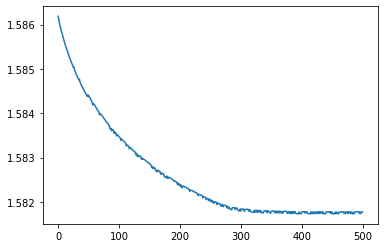

In [204]:
import matplotlib.pyplot as plt
plt.plot(np.arange(len(iter_costs)), iter_costs)

In [205]:
best_path

In [206]:
from pydrake.all import SceneGraph, MultibodyPlant, MeshcatVisualizerParams
def remap(s):
    return Ratfk.ComputeQValue(s, q_star)

gcs_traj_pgd = remap_and_toppra_trajectory(traj_pgd, remap, plant, ndim=3)
breaks_new = np.linspace(0, gcs_traj_pgd.end_time(), int(1e3), endpoint=False)
knots_full = gcs_traj_pgd.vector_values(breaks_new)

gcs_traj_og = remap_and_toppra_trajectory(traj_og, remap, plant, ndim=3)
breaks_new_og = np.linspace(0, gcs_traj_og.end_time(), int(1e3), endpoint=False)
knots_full_og = gcs_traj_og.vector_values(breaks_new_og)

In [207]:
meshcat.Delete()
#construct our robot
def plot_traj_end_effector_path(q_path, meshcat, name, diagram, plant, context, color_rgba=(1, 0, 0, 1)):
    points_local = []
    ee_frame = plant.GetFrameByName("iiwa_frame_ee")
    world_frame = plant.world_frame()
    
    for q in q_path:
        plant_context = plant.CreateDefaultContext()
        plant.SetPositions(plant_context, q)
        points_local.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())
        
    pointcloud = PointCloud(len(points_local))
    pointcloud.mutable_xyzs()[:] = np.asarray(points_local).T
    meshcat.SetObject("paths/" + name, pointcloud, 0.015, rgba=Rgba(*color_rgba))

builder = DiagramBuilder()

scene_graph = builder.AddSystem(SceneGraph())
plant = MultibodyPlant(time_step=0.0)
plant.RegisterAsSourceForSceneGraph(scene_graph)
builder.ExportInput(scene_graph.get_source_pose_port(plant.get_source_id()), "source_pose")
parser = Parser(plant)
ConfigureParser(parser)
iiwa = AddPlanarIiwa(plant)
wsg = AddWsg(plant, iiwa, roll=0.0, welded=True)
bi = parser.AddModelsFromUrl("package://manipulation/shelves.sdf")[0]
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("shelves_body", bi),
    RigidTransform([0.8, 0, 0.4]),
    )

plant.Finalize()

meshcat_visual_params = MeshcatVisualizerParams()
meshcat_visual_params.delete_on_initialization_event = False
meshcat_visual_params.role = Role.kIllustration
meshcat_visual_params.prefix = "visual"
meshcat_visual = MeshcatVisualizer.AddToBuilder(
    builder, scene_graph, meshcat, meshcat_visual_params)

meshcat_collision_params = MeshcatVisualizerParams()
meshcat_collision_params.delete_on_initialization_event = False
meshcat_collision_params.role = Role.kProximity
meshcat_collision_params.prefix = "collision"
meshcat_collision_params.visible_by_default = False
meshcat_collision = MeshcatVisualizer.AddToBuilder(
    builder, scene_graph, meshcat, meshcat_collision_params)
diagram = builder.Build()

plot_traj_end_effector_path(knots_full.T, meshcat, "newpath", diagram, plant, context, color_rgba=(1, 1, 0, 1))
plot_traj_end_effector_path(knots_full_og.T, meshcat, "og", diagram, plant, context)

builder = DiagramBuilder()
builder.AddNamedSystem('env_diagram', diagram)

pose_info = MultibodyPositionToGeometryPose(plant)
to_pose = builder.AddSystem(pose_info)
builder.Connect(to_pose.get_output_port(), diagram.GetInputPort("source_pose"))

traj_system = builder.AddSystem(TrajectorySource(gcs_traj_pgd))
builder.Connect(traj_system.get_output_port(), to_pose.get_input_port())

vizdiagram = builder.Build()
meshcat_visual = vizdiagram.GetSubsystemByName("env_diagram").GetSystems()[1]

simulator = Simulator(vizdiagram)
meshcat_visual.StartRecording()
simulator.AdvanceTo(gcs_traj_og.end_time() + 0.1)
meshcat_visual.PublishRecording()

DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindCache found /home/sgrg/.cache/drake
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:ParseModelDirectivesImpl(MultibodyPlant)
DEBUG:drake:  add_model: gripper
    package://manipulation/schunk_wsg_50_welded_fingers.sdf
DEBUG:drake:SDFormat Dbg [parser.cc:1096] Converting a deprecated source[/home/sgrg/rlg/manipulation/manipulation/models/schunk_wsg_50_welded_fingers.sdf].
DEBUG:drake:SDFormat D

In [ ]:
gcs_traj_og.end_time(), gcs_traj_pgd.end_time()

In [ ]:
gcs_traj = remap_and_toppra_trajectory(traj, remap, plant)
breaks_new = np.linspace(0, gcs_traj.end_time(), int(1e3), endpoint=False)
knots_latent = gcs_traj.vector_values(breaks_new)

knots_full = np.array([remap(knot) for knot in knots_latent.T]).T

diagrams, plants = plot_traj_swept_volume(knots_full.T, build_env, meshcat, directives_file, count=2, alpha=0.15)
plot_traj_end_effector_path(knots_full.T,
                            meshcat,
                            analytic_ik)

meshcat.SetCameraPose([-1, 0.3825, 0.75], [0, 0.3825, 0.25])
render_trajectory(meshcat, build_env, directives_file, gcs_traj, save=True, fname="nonconvex_cost.html")

latent_traj_len = np.sum(np.linalg.norm(knots_latent[:,1:] - knots_latent[:,:-1], axis=0))
true_traj_len = np.sum(np.linalg.norm(knots_full[:,1:] - knots_full[:,:-1], axis=0))
print("GCS Latent Path Length: %f" % latent_traj_len)
print("GCS True Path Length: %f" % true_traj_len)

right_len = np.sum(np.linalg.norm(knots_full[7:,1:] - knots_full[7:,:-1], axis=0))
left_len = np.sum(np.linalg.norm(knots_full[:7,1:] - knots_full[:7,:-1], axis=0))
print(f"Arm 1 path length: {right_len}")
print(f"Arm 2 path length: {left_len}")
print(f"pretty metric: {(right_len-left_len)/left_len}")

# reachability_errs = [reachability_constraint_violation(point[:7], point[7:], analytic_ik, FK_fun) for point in knots_full.T]
print("Maximum reachability distance error: %f" % np.max(reachability_errs))
plt.plot(reachability_errs)
plt.show()

with open(RepoDir() + "/data/q_full_path.pickle", "wb") as f:
    pickle.dump(knots_full.T, f)

In [ ]:
len(best_path)

In [ ]:
# dumb init
pts = np.squeeze(np.array([np.arctan(traj.value(it * traj.end_time() / 100)) for it in range(100)]))

In [ ]:
# np.hstack([pts, 0 * np.ones((pts.shape[0], 3 - pts.shape[1]))]).T
pts.shape

In [98]:
# # visualize path given trajectory
import visualization_utils as viz_utils
# viz_utils.draw_traj(visualizer.meshcat_cspace, traj, 100)
# viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj, 100, q_star=q_star)
# visualizer.animate_traj_s(traj, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_og, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_og, 100, q_star=q_star)
visualizer.animate_traj_s(traj_og, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_pgd, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_pgd, 100, q_star=q_star)
visualizer.animate_traj_s(traj_pgd, 100, 100)

## Validating Paths?

In [106]:
# take a path
# calculate the q value at each point along the trajectory
# Sum all of them
def length_of_traj(traj):
    q_prev = start_q
    dist = 0
    for i in range(50):
        s = traj.value(traj.end_time()*i/50)
        q = Ratfk.ComputeQValue(s, q_star)
        dist += ((q - q_prev).dot(q - q_prev))**0.5
        q_prev = q
    return dist
new_len = length_of_traj(traj_pgd)
og_len = length_of_traj(traj_og)
print(new_len, og_len)

7.54364600906225 8.641229878292995


In [107]:
(og_len - new_len) / og_len

0.12701708954507795

In [108]:
q_star

array([0., 0., 0., 0., 0., 0., 0.])

In [109]:
traj_og.end_time()

2.0

In [110]:
traj_pgd.end_time()

2.0

In [56]:
iter_dist = 0
values = init_values
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [57]:
iter_dist

Array(3.3586519, dtype=float32)

In [58]:
iter_dist = 0
values = [best_rounded_result.GetSolution(x) for x in variables]
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [59]:
iter_dist

Array(3.3597455, dtype=float32)

In [99]:
q_star

array([1., 1.])

## 7 DOF IIWA

In [5]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_sphere_collision_complex_scenario.dmd.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)


# oneDOF_iiwa_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/oneDOF_iiwa7_with_box_collision.sdf"
# with open(one|DOF_iiwa_file, 'r') as f:
#     oneDOF_iiwa_string = f.read()
# box_asset_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/box_small.urdf"
# with open(box_asset_file, 'r') as f:
#     box_asset_string = f.read()

In [45]:
e = traj_og.end_time()
for i in range(100):
    print(traj_og.value(e*i/100))

[[-1.69549472e+00]
 [ 8.35285831e-01]
 [-2.32222896e-01]
 [-3.77592237e-01]
 [ 2.64490807e-01]
 [ 8.30988863e-01]
 [-9.35905537e-07]]
[[-1.66237428e+00]
 [ 8.17792917e-01]
 [-2.32156676e-01]
 [-4.01845435e-01]
 [ 2.52655238e-01]
 [ 8.01188546e-01]
 [-1.25616175e-03]]
[[-1.6340342 ]
 [ 0.80282381]
 [-0.23210015]
 [-0.42259789]
 [ 0.24252803]
 [ 0.77568924]
 [-0.00233022]]
[[-1.60966807]
 [ 0.78995247]
 [-0.23205172]
 [-0.44044009]
 [ 0.23382103]
 [ 0.75376535]
 [-0.00325369]]
[[-1.58850502]
 [ 0.77877155]
 [-0.23200986]
 [-0.45593648]
 [ 0.22625879]
 [ 0.73472326]
 [-0.00405577]]
[[-1.56982076]
 [ 0.7688983 ]
 [-0.23197318]
 [-0.46961738]
 [ 0.21958249]
 [ 0.71791124]
 [-0.00476391]]
[[-1.55294871]
 [ 0.75998039]
 [-0.23194035]
 [-0.48197087]
 [ 0.21355398]
 [ 0.7027295 ]
 [-0.00540339]]
[[-1.537291  ]
 [ 0.75170183]
 [-0.23191023]
 [-0.4934347 ]
 [ 0.20795961]
 [ 0.68864007]
 [-0.00599686]]
[[-1.52232957]
 [ 0.74378879]
 [-0.2318818 ]
 [-0.50438817]
 [ 0.20261429]
 [ 0.67517679]
 [-0.0

In [34]:
def build_env(meshcat, export_sg_input=False, suffix=""):
    #construct our robot

    builder = DiagramBuilder()
    if export_sg_input:
        scene_graph = builder.AddSystem(SceneGraph())
        plant = MultibodyPlant(time_step=0.0)
        plant.RegisterAsSourceForSceneGraph(scene_graph)
        builder.ExportInput(scene_graph.get_source_pose_port(plant.get_source_id()), "source_pose")
    else:
        plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)


    parser = Parser(plant)
    ConfigureParser(parser)
    iiwa = AddPlanarIiwa(plant)
    wsg = AddWsg(plant, iiwa, roll=0.0, welded=True)
    bi = parser.AddModelsFromUrl("package://manipulation/shelves.sdf")[0]
    plant.WeldFrames(
        plant.world_frame(),
        plant.GetFrameByName("shelves_body", bi),
        RigidTransform([0.8, 0, 0.4]),
        )

    plant.Finalize()
    meshcat = StartMeshcat()
    meshcat_visual_params = MeshcatVisualizerParams()
    meshcat_visual_params.delete_on_initialization_event = False
    meshcat_visual_params.role = Role.kIllustration
    meshcat_visual_params.prefix = "visual" + suffix
    meshcat_visual = MeshcatVisualizer.AddToBuilder(
        builder, scene_graph, meshcat, meshcat_visual_params)

    meshcat_collision_params = MeshcatVisualizerParams()
    meshcat_collision_params.delete_on_initialization_event = False
    meshcat_collision_params.role = Role.kProximity
    meshcat_collision_params.prefix = "collision" + suffix
    meshcat_collision_params.visible_by_default = False
    meshcat_collision = MeshcatVisualizer.AddToBuilder(
        builder, scene_graph, meshcat, meshcat_collision_params)

    
    diagram = builder.Build()
    
    return diagram, plant, scene_graph